# Logo Recognition Clustring

This project aims to address the challenge of logo recognition and similarity search in the context of limited available datasets. Due to the vast diversity of logos and the constant emergence of new designs, traditional logo recognition systems often struggle to maintain high accuracy and robustness. To tackle this issue, the project proposes the use of synthetic data generation techniques alongside advanced deep learning models to significantly improve the system's ability to accurately identify and find similar logos.


**Notebooks:**

[Prompts Embedding](https://colab.research.google.com/drive/19DhkXGYnHh2o9k_8Iac1eFk8YI_J58Vd?usp=sharing)

[Logo Images Embedding](https://colab.research.google.com/drive/1fZhDERCptm1eYns_vpufeIYWOPCgAOyg?usp=sharing)




## Imports

In [1]:
# This get the RAPIDS-Colab install files and test check your GPU.  Run this and the next cell only.
# Please read the output of this cell.  If your Colab Instance is not RAPIDS compatible, it will warn you and give you remediation steps.
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py


Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 586, done.
remote: Counting objects: 100% (152/152), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 586 (delta 122), reused 82 (delta 82), pack-reused 434 (from 3)
Receiving objects: 100% (586/586), 191.99 KiB | 24.00 MiB/s, done.
Resolving deltas: 100% (296/296), done.
Installing RAPIDS remaining 24.12.* libraries
Using Python 3.11.11 environment at: /usr
Resolved 154 packages in 9.79s
 Downloaded libkvikio-cu12
 Downloaded rmm-cu12
 Downloaded ucx-py-cu12
 Downloaded cuspatial-cu12
 Downloaded cuda-python
 Downloaded dask
 Downloaded datashader
 Downloaded libucx-cu12
 Downloaded pylibraft-cu12
 Downloaded libcuspatial-cu12
 Downloaded cucim-cu12
 Downloaded scikit-image
 Downloaded nvidia-nvcomp-cu12
 Downloaded cudf-cu12
 Downloaded pylibcudf-cu12
 Downloaded raft-dask-cu12
 Downloaded cuml-cu12
 Downloaded libcudf-cu12
 Downloaded cuvs-cu12
 Downloaded cugraph-cu12
 Downloaded pylibcugraph-cu12

In [3]:
import cudf
import cuml

(
    cudf.__version__,
    cuml.__version__,

 )

('24.12.00', '24.12.00')

In [2]:
!pip install datasets -q

import os
import numpy as np
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
import cuml
import torch
import datasets
import warnings
warnings.filterwarnings('ignore')


output_dir = f"/content/drive/MyDrive/logo_recognition_similarity_search_project/output"
os.makedirs(output_dir,exist_ok=True)
ds_dir = f"{output_dir}/logo-recognition-embeddings"

## Load Dataset

In [25]:
ds = datasets.load_from_disk(ds_dir)
ds

Loading dataset from disk:   0%|          | 0/36 [00:00<?, ?it/s]

Dataset({
    features: ['id', 'path', 'prompt', 'prompt_embedding', 'image_embedding'],
    num_rows: 1777584
})

In [3]:
ds.features

{'id': Value(dtype='string', id=None),
 'path': Value(dtype='string', id=None),
 'prompt': Value(dtype='string', id=None),
 'prompt_embedding': Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None),
 'image_embedding': Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None)}

In [26]:
ds = ds.with_format("numpy")

In [5]:
# Extract image and text embeddings
image_embeddings = np.array(ds['image_embedding'])
prompt_embeddings = np.array(ds['prompt_embedding'])

# Concatenate image and text embeddings
combined_embeddings = np.hstack((image_embeddings, prompt_embeddings))

# # Extract text prompts
# prompts = ds['prompt']
del image_embeddings
del prompt_embeddings

combined_embeddings.shape

(1777584, 2432)

## Clustring

### UMAP

This section applies **UMAP** (Uniform Manifold Approximation and Projection) to the combined image and text embeddings. **UMAP** is a dimensionality reduction technique well-suited for visualizing high-dimensional data while preserving the underlying data structure.  The reduced embeddings are then used for clustering.  The code in this section assumes the existence of a preprocessed dataset with combined embeddings as generated in earlier parts of the notebooks.

In [6]:
from cuml.manifold import UMAP

umap_model = UMAP(n_components=50,
                  metric='cosine',
                  min_dist=0.0,
                  random_state=101,
                  verbose=True
                  )

In [7]:
reduced_embeddings = umap_model.fit_transform(combined_embeddings)
reduced_embeddings.shape

[D] [01:29:13.024239] /__w/cuml/cuml/cpp/src/umap/runner.cuh:107 n_neighbors=15
[D] [01:29:13.101814] /__w/cuml/cuml/cpp/src/umap/runner.cuh:129 Calling knn graph run
[D] [01:43:37.300430] /__w/cuml/cuml/cpp/src/umap/runner.cuh:135 Done. Calling fuzzy simplicial set
[D] [01:43:37.359225] /__w/cuml/cuml/cpp/src/umap/fuzzy_simpl_set/naive.cuh:318 Smooth kNN Distances
[D] [01:43:37.360425] /__w/cuml/cuml/cpp/src/umap/fuzzy_simpl_set/naive.cuh:320 sigmas = [ 0.100173, 0.122496, 0.0331979, 0.103231, 0.0130104, 0.136421, 0.108887, 0.0905116, 0.0691073, 0.070961, 0.087851, 0.0876267, 0.120947, 0.116036, 0.166859, 0.132617, 0.0982676, 0.117495, 0.12125, 0.106179, 0.0579612, 0.111126, 0.0264722, 0.0271819, 0.0169317 ]

[D] [01:43:37.360476] /__w/cuml/cuml/cpp/src/umap/fuzzy_simpl_set/naive.cuh:322 rhos = [ 1.13249e-06, 2.98023e-07, 0.0691797, 5.96046e-08, 0.183514, 2.98023e-07, 7.7486e-07, 1.96695e-06, 6.55651e-07, 9.53674e-07, 1.13249e-06, 1.3113e-06, 1.66893e-06, 7.15256e-07, 1.54972e-06, 1.4

(1777584, 50)

In [8]:
np.save(f"{output_dir}/reduced_embeddings.npy", reduced_embeddings)



### HDBSCAN

**HDBSCAN** (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that is well-suited for data with varying densities.  Unlike K-Means, which assumes spherical clusters of equal density, HDBSCAN can identify clusters of arbitrary shapes and sizes.  It's particularly effective at finding clusters in noisy data and identifying outliers.  We will use HDBSCAN to cluster the reduced embeddings.


In [9]:
from cuml.cluster.hdbscan import HDBSCAN

# A higher min_cluster_size will generate fewer topics
# A lower min_cluster_size will generate more topics.

hdbscan_model = HDBSCAN(min_cluster_size=50,
                        metric='euclidean',
                        cluster_selection_method='eom',
                        prediction_data=True,
                        verbose = True,
                        )


In [10]:
hdbscan_model.fit(reduced_embeddings)
soft_clusters = cuml.cluster.hdbscan.all_points_membership_vectors(hdbscan_model)

In [12]:
np.save(f"{output_dir}/labels.npy", hdbscan_model.labels_)
np.save(f"{output_dir}/soft_clusters.npy", soft_clusters)

In [13]:
hdbscan_model.labels_.shape

(1777584,)

In [40]:
hdbscan_model.n_clusters_

18

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# get the difference between top two membership probabilities for each record (exclude noise)
soft_non_noise = soft_clusters[hdbscan_model.labels_ != -1]
probs_top2_non_noise = np.take_along_axis(soft_non_noise, soft_non_noise.argsort(), axis=1)[:, -2:]
diffs = np.diff(probs_top2_non_noise).ravel()

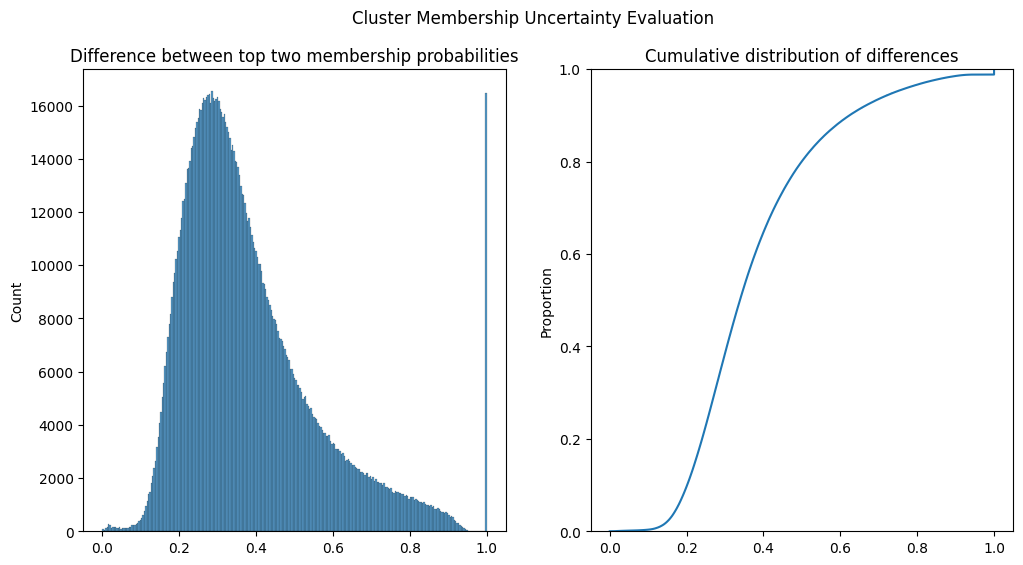

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)
fig.suptitle('Cluster Membership Uncertainty Evaluation')

sns.histplot(ax=axes[0], data=diffs)
axes[0].set_title("Difference between top two membership probabilities")

sns.ecdfplot(ax=axes[1], data=diffs)
axes[1].set_title("Cumulative distribution of differences")

fig.savefig(f"{output_dir}/soft-clustering-importance-diffs-cdf.png")



---



## Save

This section saves the clustering results (labels and soft clusters) to google drive.  These files will be used in subsequent notebooks for analysis and visualization.  The soft clusters represent the probability of each data point belonging to each cluster, providing a measure of uncertainty in the cluster assignments.

In [27]:
ds = ds.remove_columns(['image_embedding', 'prompt_embedding'])
ds = ds.add_column('cluster', hdbscan_model.labels_)
ds = ds.add_column('soft_clusters', soft_clusters.tolist())

In [28]:
ds

Dataset({
    features: ['id', 'path', 'prompt', 'cluster', 'soft_clusters'],
    num_rows: 1777584
})

In [29]:
ds.features

{'id': Value(dtype='string', id=None),
 'path': Value(dtype='string', id=None),
 'prompt': Value(dtype='string', id=None),
 'cluster': Value(dtype='int32', id=None),
 'soft_clusters': Sequence(feature=Value(dtype='float64', id=None), length=-1, id=None)}

In [31]:
ds.save_to_disk(f"{output_dir}/logo-recognition-with-clusters")

Saving the dataset (0/2 shards):   0%|          | 0/1777584 [00:00<?, ? examples/s]

In [33]:
df = ds.to_pandas().drop(columns=['soft_clusters'])
df.head()

,id,path,prompt,cluster
0,1104391803911815278,images/00/00/1104391803911815278_0_0.png,cute simple baby shark logo for company,-1
1,1104391803911815278,images/00/00/1104391803911815278_0_1.png,cute simple baby shark logo for company,12
2,1104391803911815278,images/00/00/1104391803911815278_1_0.png,cute simple baby shark logo for company,-1
3,1104391803911815278,images/00/00/1104391803911815278_1_1.png,cute simple baby shark logo for company,-1
4,1132464139621646377,images/00/00/1132464139621646377_0_0.png,"food truck, sells french fries, logo on side i...",12


In [34]:
df.shape

(1777584, 4)

In [35]:
df.to_csv(f"{output_dir}/logo-recognition-with-clusters.tsv", sep='\t', index=False)

In [36]:
df = pd.read_csv(f"{output_dir}/logo-recognition-with-clusters.tsv", sep='\t')
df.head()

,id,path,prompt,cluster
0,1104391803911815278,images/00/00/1104391803911815278_0_0.png,cute simple baby shark logo for company,-1
1,1104391803911815278,images/00/00/1104391803911815278_0_1.png,cute simple baby shark logo for company,12
2,1104391803911815278,images/00/00/1104391803911815278_1_0.png,cute simple baby shark logo for company,-1
3,1104391803911815278,images/00/00/1104391803911815278_1_1.png,cute simple baby shark logo for company,-1
4,1132464139621646377,images/00/00/1132464139621646377_0_0.png,"food truck, sells french fries, logo on side i...",12


In [ ]:
import pickle
pickle.dump(hdbscan_model, open(f"{output_dir}/hdbscan_model.pkl", "wb"))